# Project II

##### University of California - Berkeley

##### Chem277a: Data Science for the Molecular Sciences

##### Girish Krishna, Seungho Yoo, Shivani Tijare, Zander Rothering

##### Github Link: https://github.com/Zander-Rothering/Chem277a_Project_II.git

### 1) Objective

Classification of individuals as at risk for Alzheimer's disease using predictive models is critically important given its progressive, irreversible nature and status as the leading cause of dementia worldwide, representing a major and growing public health challenge (Ballard et al., 2011; Lane et al., 2018). Early detection of the disease is especially important, as Alzheimer's has a preclinical phase during which underlying pathological changes occur before clinical symptoms emerge, creating a window for intervention, improved care planning, and the potential slowing of cognitive decline through treatment (Jack et al., 2018; Lane et al., 2018). At the same time, challenges in diagnosis highlight the importance of methods that can integrate a diverse range of features such as age, cognitive scores, medical history, and other risk factors (Ballard et al., 2011). Predictive classification models are well suited to this task, as they capture relationships within data that may not be identified using conventional means. As the prevalence of Alzheimer’s continues to rise and emphasis on risk reduction becomes increasingly important, classification pipelines emerge as an effective means of enhancing diagnostic accuracy, supporting clinical decision-making, and advancing personalized medicine, contributing to improved disease management and healthcare outcomes (Ballard et al., 2011; Lane et al., 2018).

The objective of this project is to provide an overview of a classification pipeline for an Alzheimer's disease dataset using multiple models for classification. The project demonstrates how Alzheimer's data can be analyzed, preprocessed, and ultimately used by a predictive model to classify individuals as having Alzheimer's disease or not. The pipeline begins with exploratory data analysis of the dataset, providing context regarding related features, patterns in the data, and the distribution of data within the feature space. This data analysis is followed by encoding of data features into suitable values for classification models, feature selection for improved model performance, and splitting of the data into training and validation sets. Finally, the project implements and compares the classification of individuals using three models (X, Y, Z) to evaluate their ability to predict Alzheimer's disease outcomes based on input features. This systematic approach to predictive modeling, provides a concise approach to capturing the underlying relationships in data that can be used to predict Alzheimer's disease.

<br>

### 2) Dependencies

Prior to running the pipeline, the following libraries should be imported for data analysis, visualization, encoding, and predicitive modeling.

In [28]:
import warnings
warnings.filterwarnings("ignore")

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import *
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from category_encoders import BinaryEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

<br>

### 3) EDA

In [30]:
pd.set_option('display.max_columns', None)
alz_data = pd.read_csv('alzheimers_prediction_dataset.csv')
alz_data.head(15)

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Depression Level,Sleep Quality,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,Normal,No,90,Low,Poor,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,Normal,No,65,Low,Good,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,Normal,No,43,High,Good,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,Normal,No,81,Medium,Average,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,Normal,No,49,High,Poor,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No
5,Spain,55,Female,2,34.0,Medium,Current,Never,No,No,High,Yes,36,Low,Average,Healthy,Low,Retired,Married,No,Low,Medium,High,Rural,No
6,South Korea,91,Female,18,24.1,High,Former,Occasionally,No,Yes,Normal,No,68,High,Poor,Average,High,Employed,Widowed,No,High,Low,Medium,Urban,No
7,China,67,Female,11,23.6,Low,Current,Regularly,No,No,High,No,49,Low,Good,Unhealthy,Low,Unemployed,Widowed,No,Low,Medium,High,Urban,Yes
8,China,84,Female,11,22.0,High,Current,Regularly,No,No,High,No,55,Low,Good,Average,High,Employed,Single,No,Medium,Low,Low,Rural,No
9,Germany,72,Female,11,32.4,Medium,Never,Occasionally,No,Yes,Normal,Yes,50,High,Poor,Average,High,Employed,Single,No,Low,Low,Medium,Rural,No


In [31]:
alz_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               74283 non-null  object 
 1   Age                                   74283 non-null  int64  
 2   Gender                                74283 non-null  object 
 3   Education Level                       74283 non-null  int64  
 4   BMI                                   74283 non-null  float64
 5   Physical Activity Level               74283 non-null  object 
 6   Smoking Status                        74283 non-null  object 
 7   Alcohol Consumption                   74283 non-null  object 
 8   Diabetes                              74283 non-null  object 
 9   Hypertension                          74283 non-null  object 
 10  Cholesterol Level                     74283 non-null  object 
 11  Family History 

In [32]:
alz_data.nunique()

Country                                  20
Age                                      45
Gender                                    2
Education Level                          20
BMI                                     166
Physical Activity Level                   3
Smoking Status                            3
Alcohol Consumption                       3
Diabetes                                  2
Hypertension                              2
Cholesterol Level                         2
Family History of Alzheimer’s             2
Cognitive Test Score                     70
Depression Level                          3
Sleep Quality                             3
Dietary Habits                            3
Air Pollution Exposure                    3
Employment Status                         3
Marital Status                            3
Genetic Risk Factor (APOE-ε4 allele)      2
Social Engagement Level                   3
Income Level                              3
Stress Levels                   

In [33]:
# Feature Separation
alz_target = alz_data["Alzheimer’s Diagnosis"]
alz_data_x = alz_data.drop(["Alzheimer’s Diagnosis"], axis = 1)
alz_data_copy = alz_data_x.copy()

# Numeric Feature
numeric_data = ['Age', 'BMI', 'Cognitive Test Score', 'Education Level']
alz_numeric = alz_data_copy[numeric_data]
alz_numeric.head()

,Age,BMI,Cognitive Test Score,Education Level
0,90,33.0,90,1
1,72,29.9,65,7
2,86,22.9,43,19
3,53,31.2,81,17
4,58,30.0,49,3


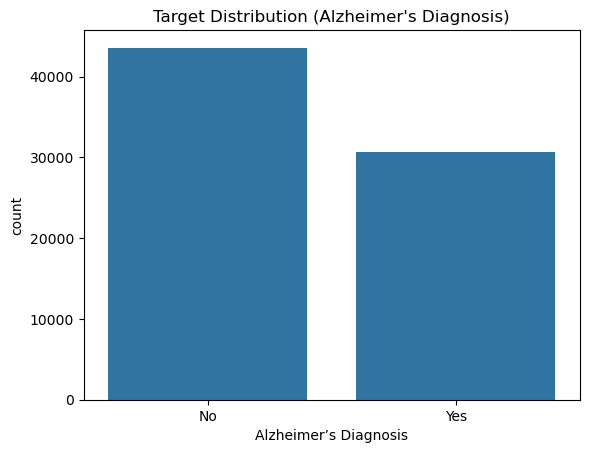

In [34]:
# Target Distribution
alz_target.value_counts(normalize=True)
sns.countplot(x=alz_target)
plt.title("Target Distribution (Alzheimer's Diagnosis)")
plt.show()

<Axes: >

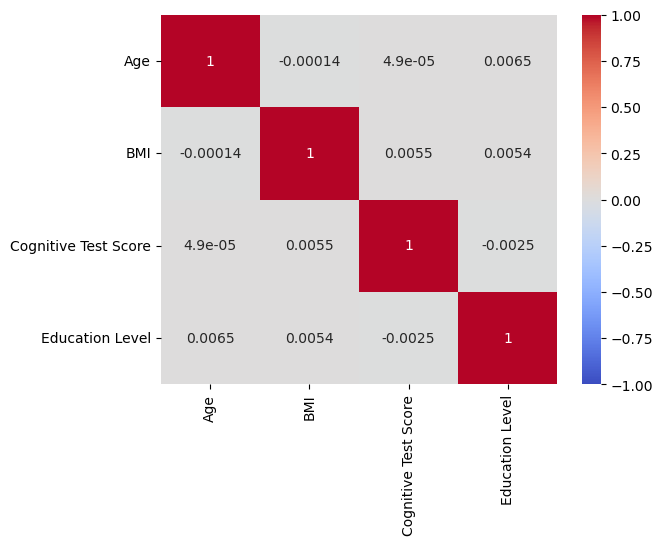

In [35]:
sns.heatmap(alz_numeric.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

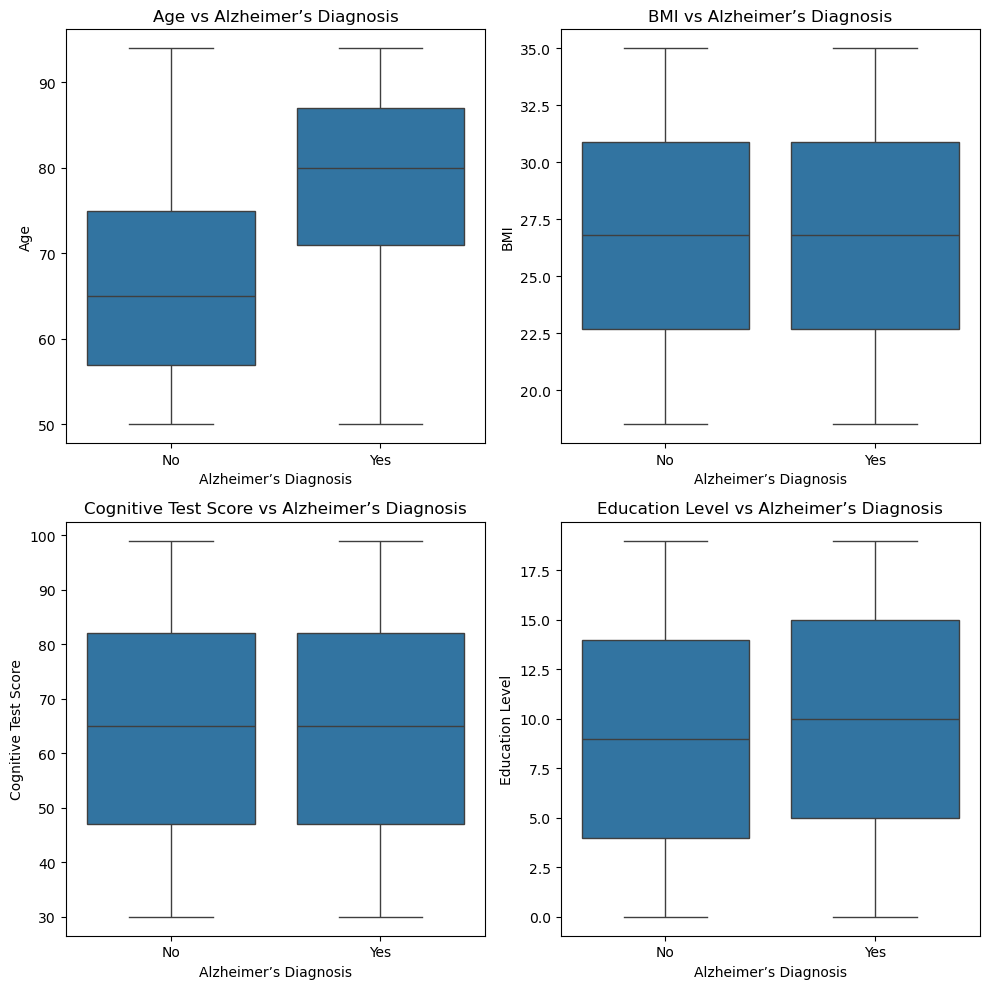

In [36]:
alz_columns_num = alz_numeric.columns.tolist()

cols = len(alz_columns_num)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for i, column in enumerate(alz_columns_num):
    sns.boxplot(data=alz_data, x="Alzheimer’s Diagnosis", y=column, ax=axes[i])
    axes[i].set_title(f"{column} vs Alzheimer’s Diagnosis")
plt.tight_layout()
plt.show()

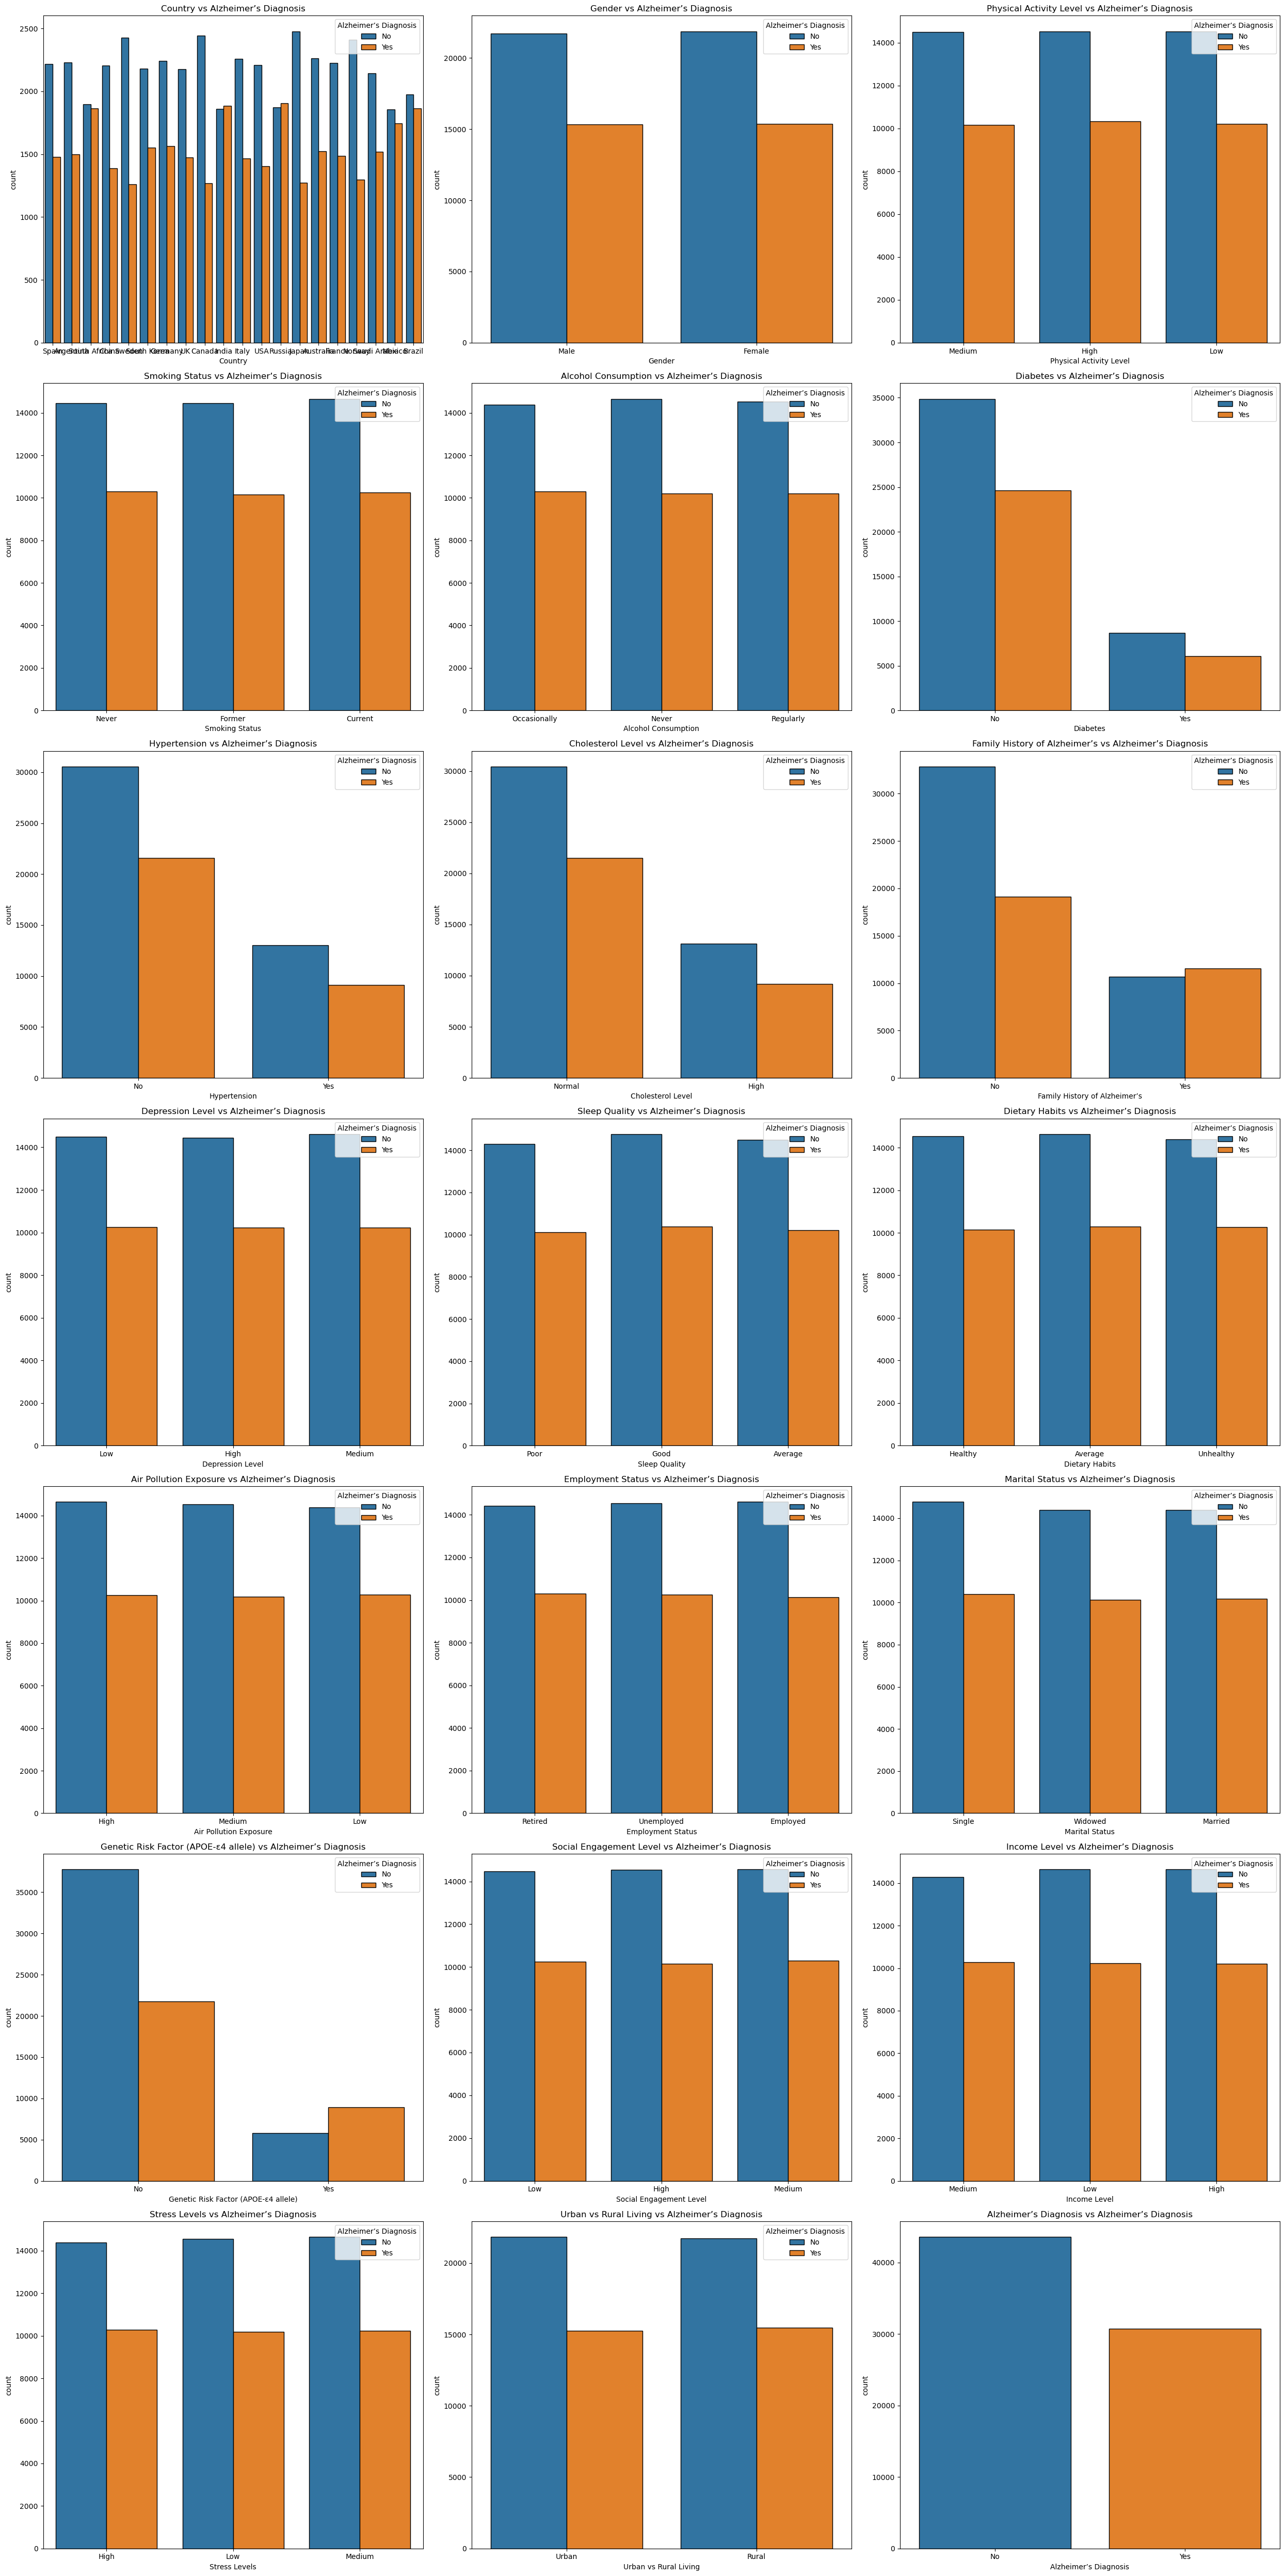

In [37]:
alz_data_cat = alz_data.drop(columns=numeric_data)
alz_columns_cat = alz_data_cat.columns.tolist()

fig, axes = plt.subplots(7, 3, figsize=(25, 50))
axes = axes.flatten()

for i, column in enumerate(alz_columns_cat):
    sns.countplot(data=alz_data, x=column, hue="Alzheimer’s Diagnosis", ax=axes[i], edgecolor='black')
    axes[i].set_title(f"{column} vs Alzheimer’s Diagnosis")

plt.tight_layout()
plt.show()

In [38]:
# Correlation

from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(alz_numeric, alz_target)
pd.Series(mi, index=alz_numeric.columns).sort_values(ascending=False)

Age                     0.108400
BMI                     0.000179
Cognitive Test Score    0.000000
Education Level         0.000000
dtype: float64

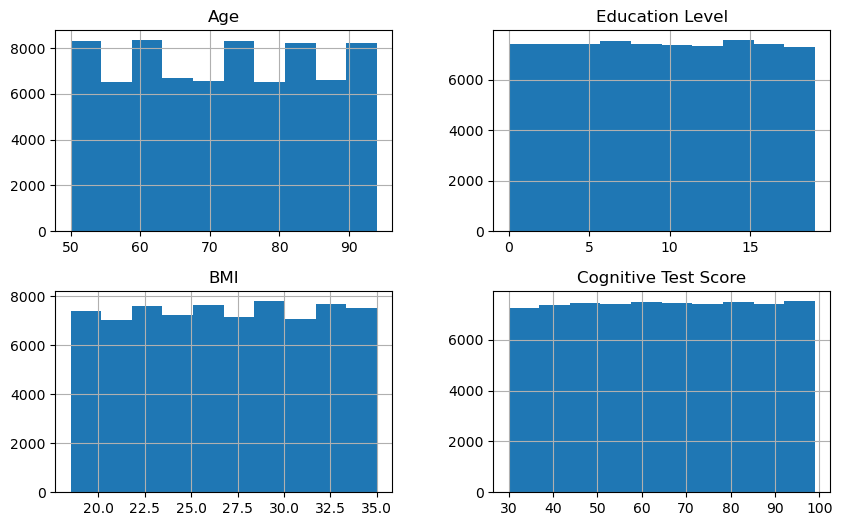

In [41]:
# Distribution + Outliers

df_alz[numeric_features].hist(figsize=(10,6))
plt.show()

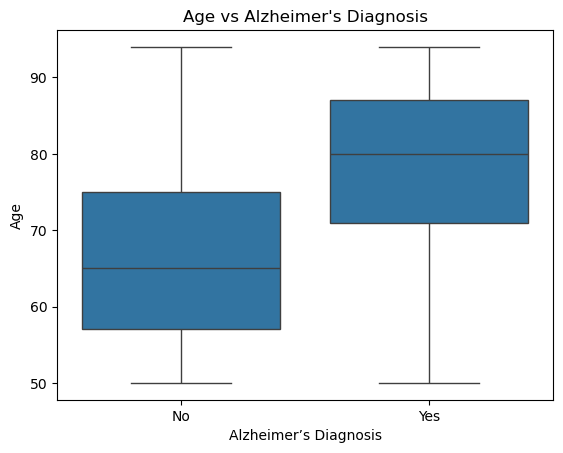

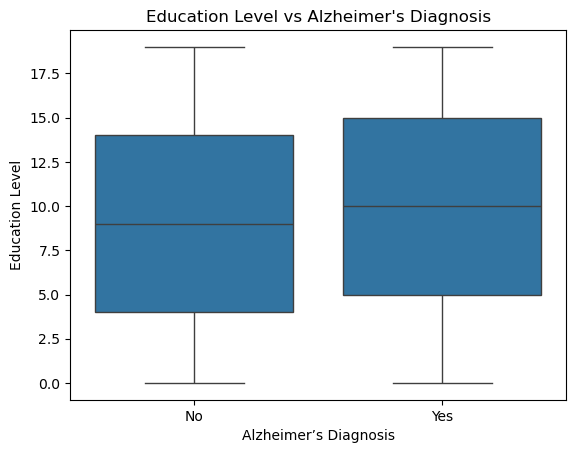

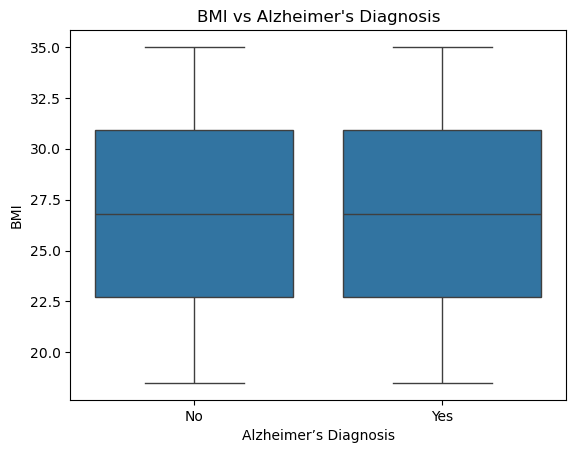

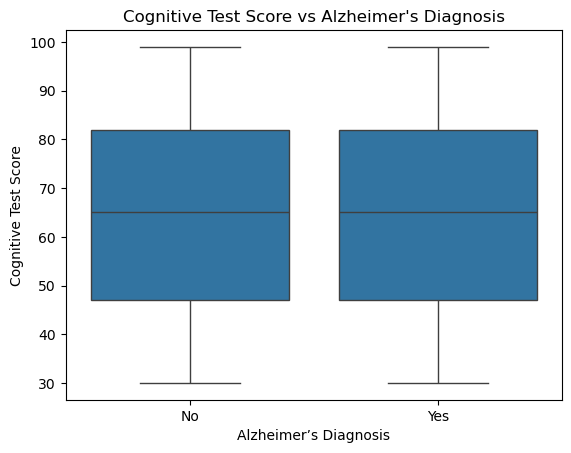

In [40]:
# Boxplots with interpretation
for col in numeric_features:
    sns.boxplot(x=alz_target, y=alz_data[col])
    plt.title(f"{col} vs Alzheimer's Diagnosis")
    plt.show()

In [48]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

cat_encoded = alz_data_cat.apply(LabelEncoder().fit_transform)
chi_scores, p_vals = chi2(cat_encoded, alz_target)
chi_results = pd.DataFrame({
    "Feature": cat_encoded.columns,
    "p-value": p_vals
}).sort_values(by="p-value")

chi_results

,Feature,p-value
20,Alzheimer’s Diagnosis,0.000000e+00
15,Genetic Risk Factor (APOE-ε4 allele),0.000000e+00
8,Family History of Alzheimer’s,1.800110e-226
0,Country,5.922741e-02
17,Income Level,1.667019e-01
18,Stress Levels,2.991860e-01
3,Smoking Status,4.104049e-01
19,Urban vs Rural Living,4.285532e-01
13,Employment Status,4.342582e-01
11,Dietary Habits,4.699847e-01


### 4) Feature Encoding

In [49]:
df_alz = alz_data_x.copy()
binary_features = ['Gender', 'Smoking Status', 'Alcohol Consumption', 'Diabetes', 'Hypertension', 
                   'Cholesterol Level', 'Family History of Alzheimer’s', 'Sleep Quality', 'Dietary Habits', 'Employment Status',
                   'Marital Status', 'Genetic Risk Factor (APOE-ε4 allele)', 'Urban vs Rural Living']
ordinal_features = ['Physical Activity Level', 'Depression Level', 'Air Pollution Exposure', 'Social Engagement Level', 
                    'Income Level', 'Stress Levels']
numeric_features = ['Age', 'Education Level', 'BMI', 'Cognitive Test Score']
high_card_features = ['Country']


# Binary/nominal encoding (one-hot, drop first to avoid multicollinearity)
df_alz_bin = pd.get_dummies(df_alz, columns=binary_features, drop_first=True)
df_alz_bin = df_alz_bin.drop(columns=ordinal_features + high_card_features).astype(int)

#Ordinal Encoding - explicit category order per feature
ordinal_categories = [
    ['Low', 'Medium', 'High'],  # Physical Activity Level
    ['Low', 'Medium', 'High'],  # Depression Level
    ['Low', 'Medium', 'High'],  # Air Pollution Exposure
    ['Low', 'Medium', 'High'],  # Social Engagement Level
    ['Low', 'Medium', 'High'],  # Income Level
    ['Low', 'Medium', 'High'],  # Stress Levels
]

ord_encoder = OrdinalEncoder(categories= ordinal_categories)
df_ordinal = df_alz[ordinal_features].copy()
df_ordinal[ordinal_features] = ord_encoder.fit_transform(df_ordinal[ordinal_features])

#binary for high cardinality feature
bin_encoder = BinaryEncoder(cols=['Country'])
df_country = bin_encoder.fit_transform(df_alz[high_card_features].copy())

#joining all encoded pieces, not doing scaling yet
df_alz_encoded = df_country.join([df_alz_bin, df_ordinal], how='outer')
df_alz_encoded.head()

,Country_0,Country_1,Country_2,Country_3,Country_4,Age,Education Level,BMI,Cognitive Test Score,Gender_Male,Smoking Status_Former,Smoking Status_Never,Alcohol Consumption_Occasionally,Alcohol Consumption_Regularly,Diabetes_Yes,Hypertension_Yes,Cholesterol Level_Normal,Family History of Alzheimer’s_Yes,Sleep Quality_Good,Sleep Quality_Poor,Dietary Habits_Healthy,Dietary Habits_Unhealthy,Employment Status_Retired,Employment Status_Unemployed,Marital Status_Single,Marital Status_Widowed,Genetic Risk Factor (APOE-ε4 allele)_Yes,Urban vs Rural Living_Urban,Physical Activity Level,Depression Level,Air Pollution Exposure,Social Engagement Level,Income Level,Stress Levels
0,0,0,0,0,1,90,1,33,90,1,0,1,1,0,0,0,1,0,0,1,1,0,1,0,1,0,0,1,1.0,0.0,2.0,0.0,1.0,2.0
1,0,0,0,1,0,72,7,29,65,1,1,0,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0,1,1.0,0.0,1.0,2.0,0.0,2.0
2,0,0,0,1,1,86,19,22,43,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,2.0,2.0,1.0,0.0,1.0,2.0
3,0,0,1,0,0,53,17,31,81,1,0,1,0,1,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0.0,1.0,1.0,2.0,1.0,0.0
4,0,0,1,0,1,58,3,30,49,0,1,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,2.0,2.0,2.0,0.0,1.0,2.0


### 4.5) Feature Selection

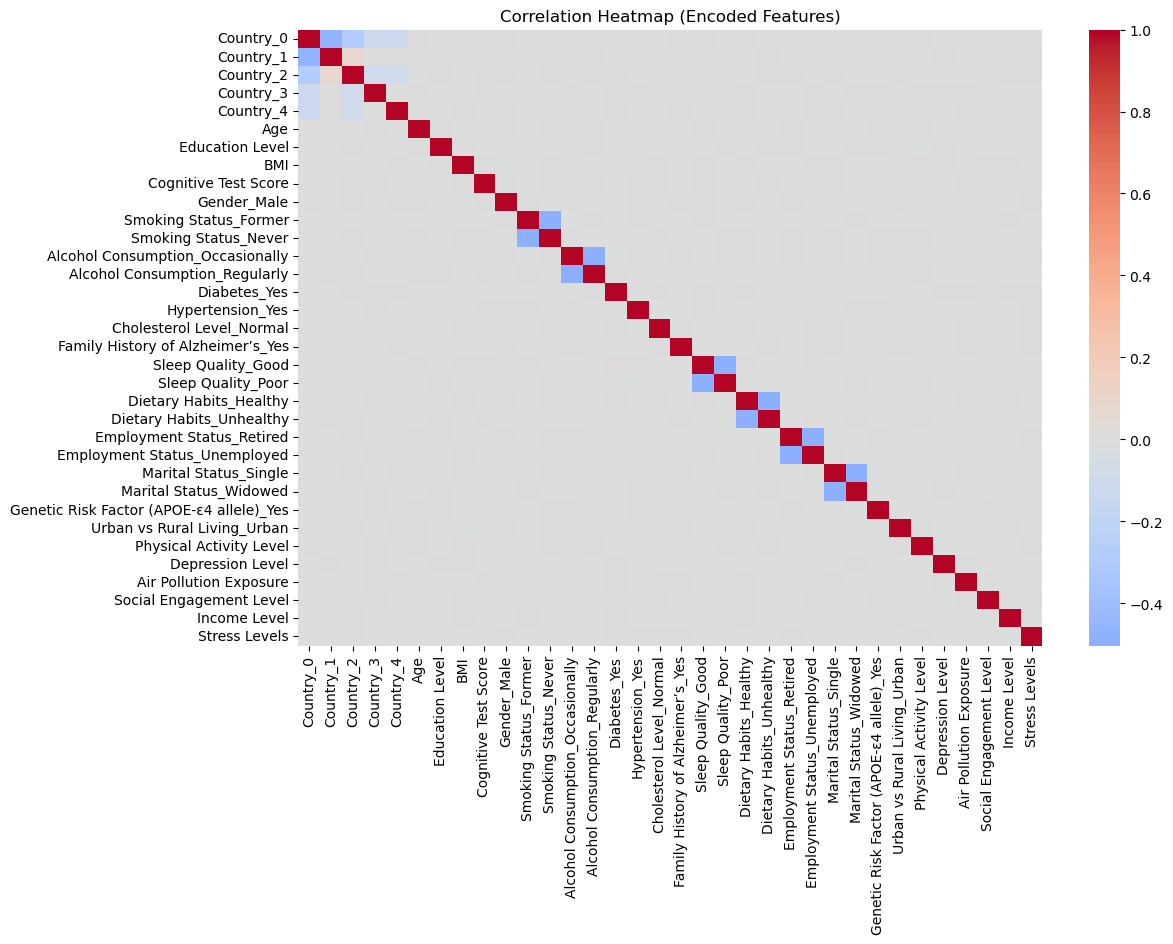

In [50]:
# Correlation on FULL encoded dataset

corr = df_alz_encoded.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Encoded Features)")
plt.show()

The correlation heatmap of encoded features shows that more of the features are independent of one another. The only notable correlations appear within dummy-encoded groups like Smoking Status_Former and Smoking Status_Never are negatively correlated which is expected. This absence of multicollinearity suggests that feature redundancy is not really a major concern and indepented information will be carried into the models.

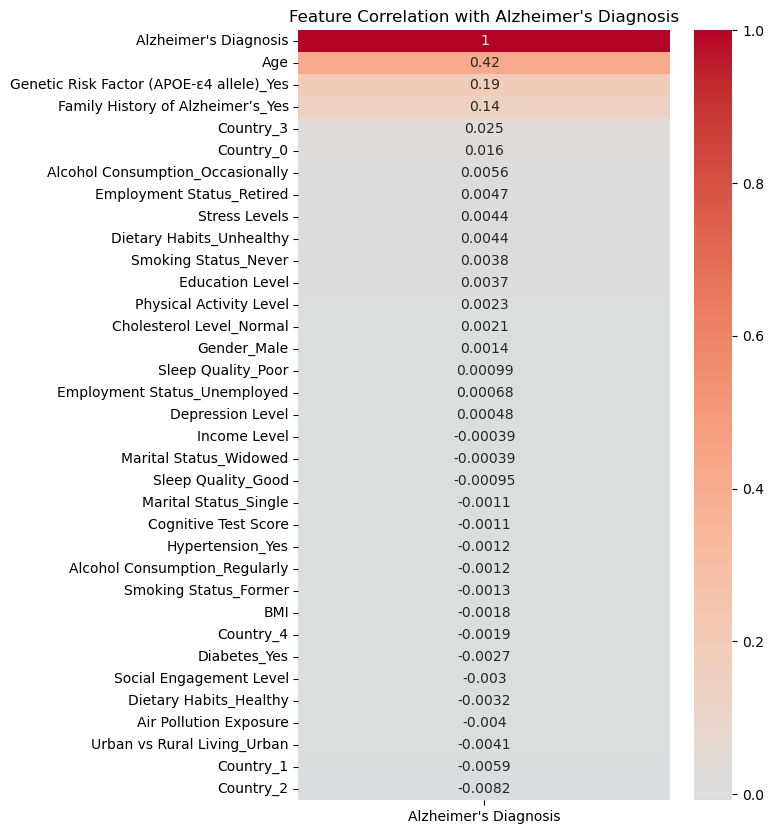

In [51]:
# correlation with target

# Make a copy so we do not change the original encoded dataframe
df_corr = df_alz_encoded.copy()

# Add target back into the encoded dataframe
df_corr["Alzheimer's Diagnosis"] = alz_target.map({"No": 0, "Yes": 1})

# Correlation with target
corr_target = df_corr.corr()["Alzheimer's Diagnosis"].sort_values(ascending=False)
plt.figure(figsize=(6,10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation with Alzheimer's Diagnosis")
plt.show()

Here age shows the strongest linear correlation with the Alxzheimer's diagnosis (r = 0.42), which is consistent witht eh mutual information results. Genetic Risk Factor (APOE-ε4 allele) (r = 0.19) and Family History of Alzheimer's (r = 0.14) follow as the next most correlated features. The rest of the fetures show correlations close to 0 which suggests a weaker linear relationship with the target.

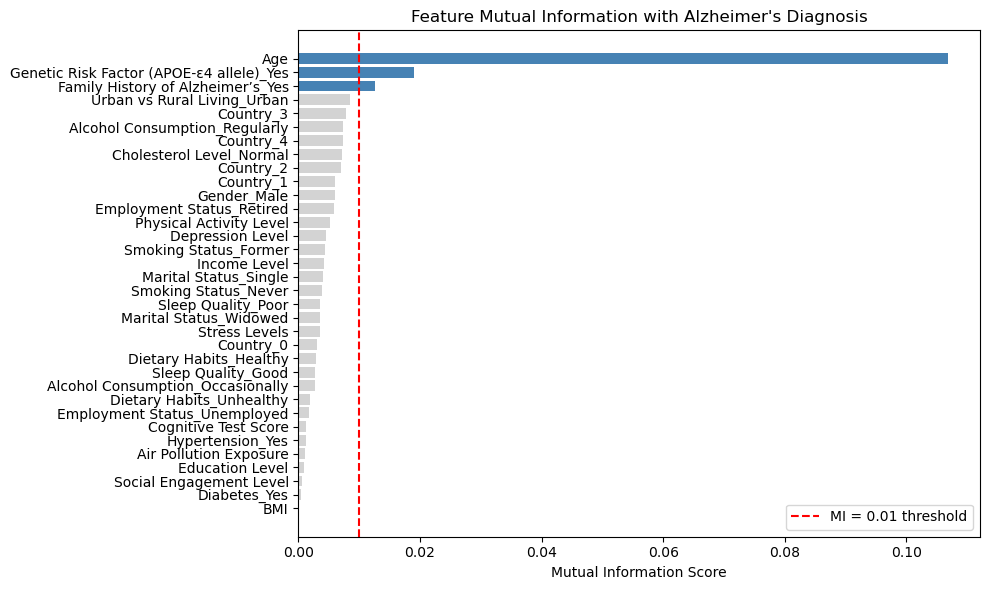

In [53]:
from sklearn.feature_selection import mutual_info_classif

# Make a clean X and y
X_mi = df_alz_encoded.copy()
y_mi = alz_target.map({"No": 0, "Yes": 1})

# Mutual information
mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

#viewing as a bar chart
plt.figure(figsize=(10, 6))
mi_series_plot = mi_series[mi_series.index != "Alzheimer's Diagnosis"]
colors = ['steelblue' if v >= 0.01 else 'lightgray' for v in mi_series_plot]
plt.barh(mi_series_plot.index[::-1], mi_series_plot.values[::-1], color=colors[::-1])
plt.axvline(x=0.01, color='red', linestyle='--', label='MI = 0.01 threshold')
plt.xlabel('Mutual Information Score')
plt.title('Feature Mutual Information with Alzheimer\'s Diagnosis')
plt.legend()
plt.tight_layout()
plt.show()

The mutual information scores show that there is a highly skewed distribution of predictive power across the features/ Age dominates by a pretty large marging where the MI is around 0.11, and then Genertifc Risk Factor (APOE-ε4 allele) and Family History of Alzeihmer's. This is consistent with established clinical literature on Alzheimer's risk. The majority of the remaining features fall under the 0.01 threshold including features like BMI, Diabetes, and Education Level. This sugges that they have limited indicidual predictive dependency with the target, but these features should still be kept for modeling. This is becuase their collective contribution might improve classification performance and removing then just based on MI could risk eliminating their interaction effects that might be captured by more complex models.

### 5) Models

<br>

### 6) Improvements

<br>

### 7) Discussion

<br>

### References

###### 1. Ankit. (2025). Alzheimer’s Prediction Dataset (Global) [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/10618775
###### 2. Ballard, C., Gauthier, S., Corbett, A., Brayne, C., Aarsland, D., & Jones, E. (2011). Alzheimer’s disease. The Lancet, 377(9770), 1019–1031. https://doi.org/10.1016/S0140-6736(10)61349-9
###### 3. Lane, C. A., Hardy, J., & Schott, J. M. (2018). Alzheimer’s disease. European Journal of Neurology, 25(1), 59–70. https://doi.org/10.1111/ene.13439
###### 4. Jack, C. R., Bennett, D. A., Blennow, K., Carrillo, M. C., Dunn, B., Haeberlein, S. B., Holtzman, D. M., Jagust, W., Jessen, F., Karlawish, J., Liu, E., Molinuevo, J. L., Montine, T., Phelps, C., Rankin, K. P., Rowe, C. C., Scheltens, P., Siemers, E., Snyder, H. M., & Sperling, R. (2018). NIA-AA research framework: Toward a biological definition of Alzheimer’s disease. Alzheimer’s & Dementia, 14(4), 535–562. https://doi.org/10.1016/j.jalz.2018.02.018
###### 5.